<a href="https://colab.research.google.com/github/adityaraghavan98/camm_hackathon/blob/k4my4r/docs/day_17_18092026/Aditya_EELS_descriptors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2:  <font color = "red">**Structure → Property Challenge**</font>

Can local image structure predict the local EELS response?

For each location, we have:

**Image patch → EELS spectrum → Scalarizer**

Your task is to:

1. Build a <font color = "purple">**descriptor**</font> for the image patch.
2. Use a <font color = "purple">**regressor**</font> to predict a scalarizer or the full spectrum.
3. Compare methods by:
   - predictive power
   - complexity
   - explainability

<font color = "green">**Goal**</font>

> Find the simplest explainable descriptor that predicts the EELS response well.

## <font color = "purple">**1.**</font> Explore the Dataset

Each spatial location contains:

- one image intensity value
- one full EELS spectrum

The same position in the image corresponds to the same position in the EELS spectrum image.

Let's look at one dataset.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_17_18092026/notebook.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import os

In [2]:
!gdown --fuzzy 1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6

Downloading...
From (original): https://drive.google.com/uc?id=1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6
From (redirected): https://drive.google.com/uc?id=1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6&confirm=t&uuid=d7f20dc6-b704-4287-b17b-7d570d829a38
To: /content/Plasmonic_sets_hackathon.npy
100% 584M/584M [00:08<00:00, 68.7MB/s]


In [3]:
file_name = "/content/Plasmonic_sets_hackathon.npy"

raw = np.load(
    file_name,
    allow_pickle=True
)

loadedfile = raw.tolist()
print("keys:", loadedfile.keys())

keys: dict_keys(['0', '1', '2', '3'])


In [4]:
# Choose dataset
data = loadedfile["2"]

image = data["image"]
spectra = data["spectrum image"]
energy = data["energy axis"]

H, W = image.shape

print(image.shape)
print(spectra.shape)
print(energy.shape)

(33, 63)
(33, 63, 4322)
(4322,)


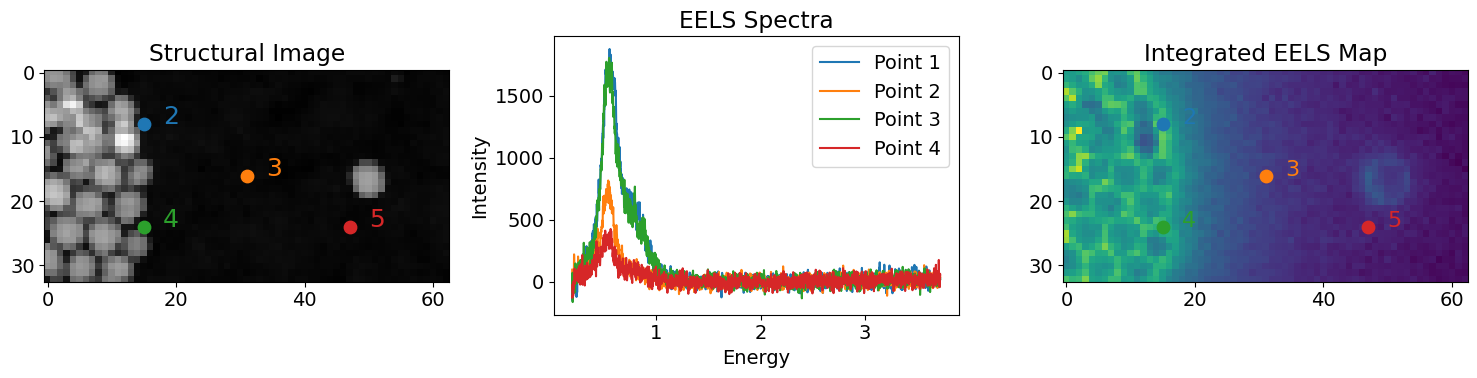

In [5]:
# Example locations
positions = [
    (H // 4, W // 4),
    (H // 2, W // 2),
    (3 * H // 4, W // 4),
    (3 * H // 4, 3 * W // 4),
]

colors = ["C0", "C1", "C2", "C3"]

# Integrated EELS map
eels_map = spectra.sum(axis=2)

plt.rcParams.update({"font.size": 14})

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Structural image
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

# Spectra
for i, ((y, x), color) in enumerate(zip(positions, colors)):

    ax[0].scatter(x, y, s=80, color=color)
    ax[0].text(x + 3, y, str(i + 2), color=color, fontsize=18)

    ax[1].plot(
        energy,
        spectra[y, x],
        color=color,
        label=f"Point {i + 1}"
    )

    ax[2].scatter(x, y, s=80, color=color)
    ax[2].text(x + 3, y, str(i + 2), color=color, fontsize=16)

ax[1].set_title("EELS Spectra")
ax[1].set_xlabel("Energy")
ax[1].set_ylabel("Intensity")
ax[1].legend()

# EELS map
ax[2].imshow(eels_map)
ax[2].set_title("Integrated EELS Map")

plt.tight_layout()
plt.show()

## <font color = "purple">**2.**</font> Define a Scalarizer

Each EELS spectrum can be reduced to a **single target value** called a scalarizer.

For example, the spectral intensity within an energy window:

$$
S(x,y)=\int_{E_1}^{E_2} I(x,y,E)\,dE
$$

where \(E_1\) and \(E_2\) define the spectral region of interest.

Other possible scalarizers include:

- peak intensity
- peak position
- peak area
- peak ratio

## <font color = "purple">**3.**</font> Choose a Spectral Region

Before defining the scalarizer, inspect the EELS spectrum and choose an energy range containing a feature of interest.

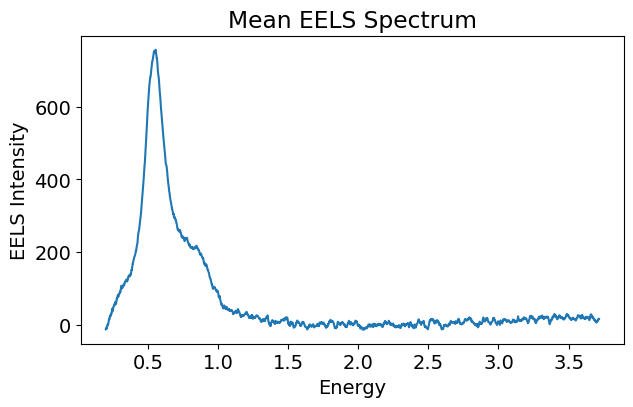

In [6]:
# Mean spectrum over the whole image
mean_spectrum = spectra.mean(axis=(0, 1))

plt.figure(figsize=(7, 4))

plt.plot(energy, mean_spectrum)

plt.xlabel("Energy")
plt.ylabel("EELS Intensity")
plt.title("Mean EELS Spectrum")

plt.show()

## <font color = "purple">**4.**</font> Calculate the Scalarizer

We integrate the EELS intensity inside the selected energy window to obtain one target value at each spatial location.

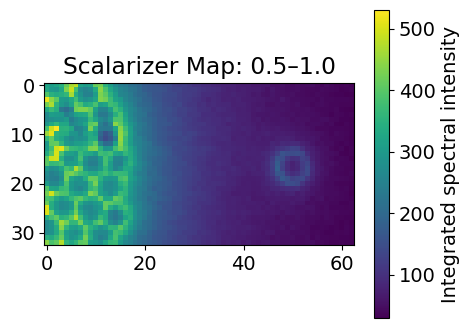

In [7]:
# Choose an energy range
E1 = 0.5
E2 = 1.0

mask = (energy >= E1) & (energy <= E2)

scalarizer_map = np.trapezoid(
    spectra[:, :, mask],
    energy[mask],
    axis=2
)

plt.figure(figsize=(5, 4))
plt.imshow(scalarizer_map)
plt.colorbar(label="Integrated spectral intensity")
plt.title(f"Scalarizer Map: {E1}–{E2}")
plt.show()

### <font color = "purple">**4A.**</font> Explore the Full EELS Response with PCA

The 0.5–1.0 eV integral is a useful baseline, but it uses only one manually selected energy window. To check whether the **full EELS spectrum** contains other spatially localized responses, we apply PCA to the **unnormalized spectra**.

Here PCA is used only on the **property side**: each full EELS spectrum is represented by a small number of independent spectral modes. We keep the spectra unnormalized so that both spectral shape and physically measured intensity variations are retained.

We will inspect the spatial score map and spectral loading of each component before choosing any PCA component as a scalarizer.


In [8]:
from sklearn.decomposition import PCA

# Flatten the EELS cube: one row = one spatial spectrum
n_energy = spectra.shape[2]
X_spectra = spectra.reshape(-1, n_energy).astype(float)

N_COMPONENTS = 5

# IMPORTANT: no per-spectrum normalization here
pca = PCA(n_components=N_COMPONENTS)
Z = pca.fit_transform(X_spectra)

# Put PCA scores back into spatial form
pca_maps = Z.reshape(H, W, N_COMPONENTS)

print("Explained variance ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {100*var:.2f}%")

print(
    "Cumulative explained variance:",
    np.round(100*np.cumsum(pca.explained_variance_ratio_), 2)
)


Explained variance ratio:
PC1: 77.73%
PC2: 11.20%
PC3: 0.63%
PC4: 0.60%
PC5: 0.47%
Cumulative explained variance: [77.73 88.92 89.55 90.14 90.61]


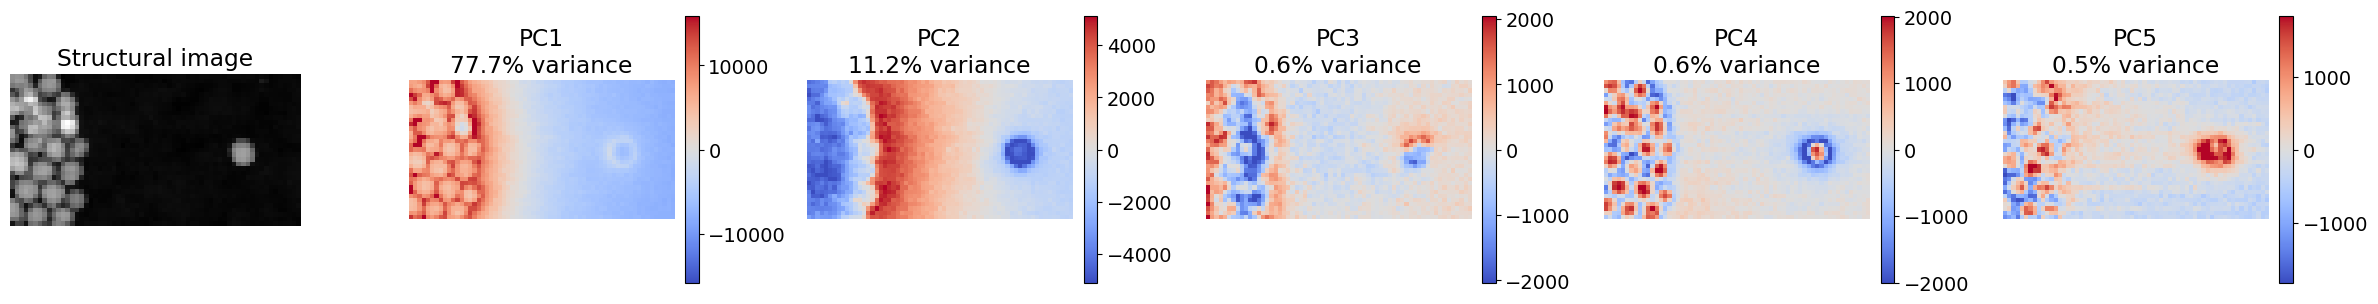

In [9]:
# Visualize the structural image and spatial maps of the first five EELS PCs
fig, ax = plt.subplots(
    1, N_COMPONENTS + 1,
    figsize=(4 * (N_COMPONENTS + 1), 4)
)

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural image")
ax[0].axis("off")

for i in range(N_COMPONENTS):
    m = pca_maps[:, :, i]
    vmax = np.nanpercentile(np.abs(m), 99)

    im = ax[i + 1].imshow(
        m,
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax
    )

    ax[i + 1].set_title(
        f"PC{i+1}\n"
        f"{100*pca.explained_variance_ratio_[i]:.1f}% variance"
    )
    ax[i + 1].axis("off")
    plt.colorbar(im, ax=ax[i + 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### Why focus on PC4?

The leading components capture the largest overall spectral variations, but **PC4 is especially interesting for this structure–property challenge because its spatial score map resolves individual particle-associated features**. In particular, the PC4 map shows opposite-sign contrast between regions associated with the **particle interior/bulk and the surrounding particle edge**.

This makes PC4 useful as a data-driven scalarizer for asking a more specific question:

> **Can simple local image structure predict the particle-associated EELS spectral variation represented by PC4?**

We are **not** assigning PC4 to a specific plasmonic mechanism here. We treat it as an experimentally observed spectral mode whose spatial localization makes it relevant to local structure.


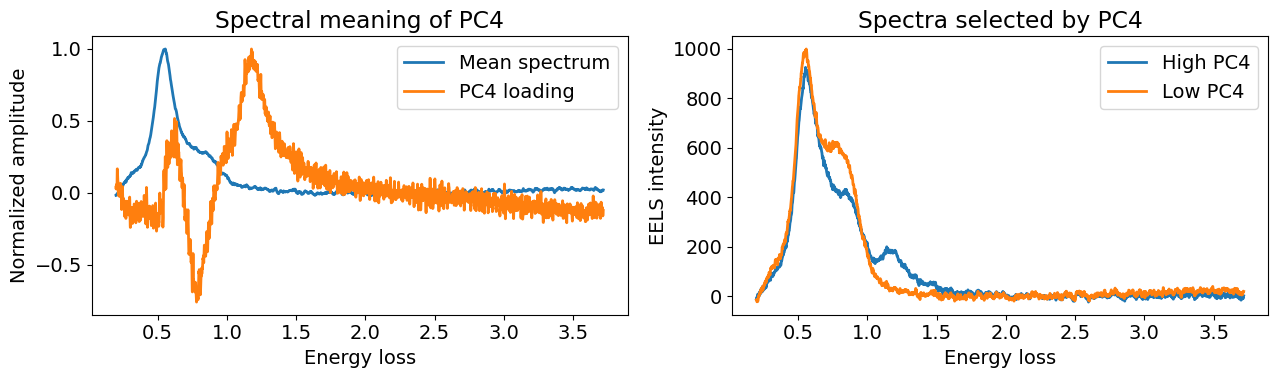

In [10]:
# Inspect what spectral change PC4 represents
pc4_scores = Z[:, 3]
N_SELECT = min(100, len(pc4_scores) // 10)

idx_high = np.argsort(pc4_scores)[-N_SELECT:]
idx_low  = np.argsort(pc4_scores)[:N_SELECT]

mean_high = X_spectra[idx_high].mean(axis=0)
mean_low  = X_spectra[idx_low].mean(axis=0)

# PC4 loading, rescaled only for visualization beside the mean spectrum
mean_spec = X_spectra.mean(axis=0)
mean_scaled = mean_spec / (np.max(np.abs(mean_spec)) + 1e-12)
pc4_loading_scaled = pca.components_[3] / (np.max(np.abs(pca.components_[3])) + 1e-12)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(energy, mean_scaled, label="Mean spectrum", linewidth=2)
ax[0].plot(energy, pc4_loading_scaled, label="PC4 loading", linewidth=2)
ax[0].set_xlabel("Energy loss")
ax[0].set_ylabel("Normalized amplitude")
ax[0].set_title("Spectral meaning of PC4")
ax[0].legend()

ax[1].plot(energy, mean_high, label="High PC4", linewidth=2)
ax[1].plot(energy, mean_low, label="Low PC4", linewidth=2)
ax[1].set_xlabel("Energy loss")
ax[1].set_ylabel("EELS intensity")
ax[1].set_title("Spectra selected by PC4")
ax[1].legend()

plt.tight_layout()
plt.show()


### Use PC4 as the scalarizer

The original 0.5–1.0 eV integral remains our baseline. For the remainder of this notebook, we use the **PC4 score** as the property scalarizer because it highlights localized particle bulk/edge spectral contrast that is not obvious from the dominant broad spectral variation.


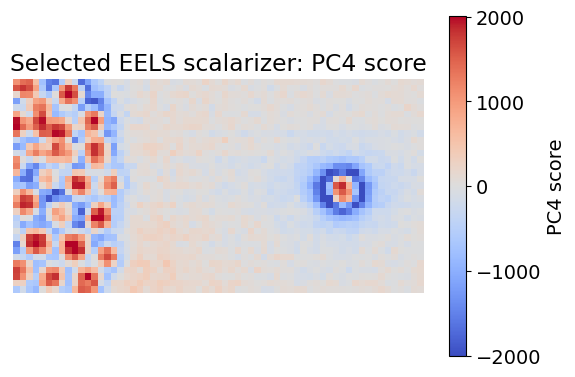

In [11]:
# PC4 score at each spatial position becomes the new scalarizer
scalarizer_map = pca_maps[:, :, 3].copy()

vmax = np.nanpercentile(np.abs(scalarizer_map), 99)

plt.figure(figsize=(6, 4))
im = plt.imshow(
    scalarizer_map,
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax
)
plt.colorbar(im, label="PC4 score")
plt.title("Selected EELS scalarizer: PC4 score")
plt.axis("off")
plt.tight_layout()
plt.show()


## <font color = "purple">**5.**</font> Create Patch–Spectrum–Scalarizer Pairs

For each location we collect:

**Image patch → EELS spectrum → PC4 scalarizer**

The EELS spectrum and PC4 score correspond to the center pixel of the image patch. We use a **3×3 local patch** so the descriptor sees the measurement point together with its immediate neighborhood while remaining simple and local.


In [12]:
PATCH_SIZE = 3
half = PATCH_SIZE // 2

patches = []
targets = []
coords = []

for y in range(half, H - half):
    for x in range(half, W - half):

        patch = image[y-half:y+half+1, x-half:x+half+1]

        patches.append(patch)
        targets.append(scalarizer_map[y, x])
        coords.append((y, x))

patches = np.asarray(patches)
targets = np.asarray(targets)
coords = np.asarray(coords)

print("Patches:", patches.shape)
print("Targets:", targets.shape)


Patches: (1891, 3, 3)
Targets: (1891,)


## <font color = "purple">**6.**</font> Look at Example Pairs

Each patch has one target scalarizer value.

Can you see structural differences between low and high target values?

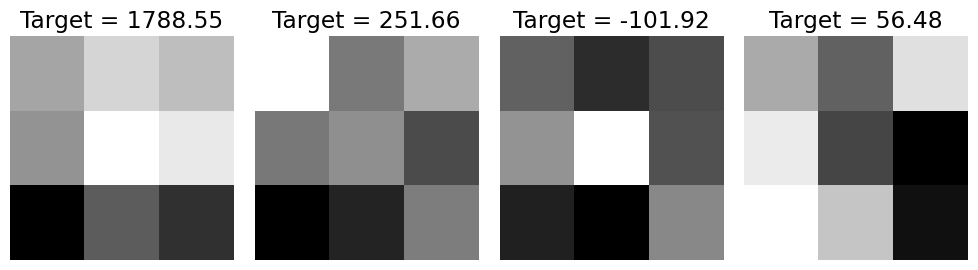

In [13]:
fig, ax = plt.subplots(1, 4, figsize=(10, 3))

ids = np.linspace(0, len(patches) - 1, 4, dtype=int)

for i, idx in enumerate(ids):
    ax[i].imshow(patches[idx], cmap="gray")
    ax[i].set_title(f"Target = {targets[idx]:.2f}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()

## The Challenge

You will design two parts of the prediction pipeline:

**Image Patch → Descriptor → Regressor → EELS Scalarizer**

### Your goal

Find a combination with:

- high predictive power
- low complexity
- good explainability

You can change:

1. the **descriptor** — how the image patch is represented
2. the **regressor** — how the descriptor is mapped to the EELS property

Try different combinations and compare their performance.

## <font color = "purple">**7.**</font> Define the Structural Descriptor and Regressor

PC4 appears to distinguish particle-associated bulk/interior and edge response. Therefore the structural descriptor should contain simple quantities that can distinguish:

- **local intensity** — how bright/material-like the local region is,
- **local heterogeneity** — whether the patch is uniform or structurally mixed,
- **local contrast** — the intensity span within the patch,
- **edge strength** — whether the patch contains a strong structural boundary,
- **center-to-neighborhood contrast** — whether the EELS measurement point differs from its immediate surroundings.

These are deliberately hand-crafted and low complexity so that every feature has a direct interpretation. We begin with a linear regressor as the simplest explainable mapping from structure to the PC4 EELS response.


In [14]:
from scipy.ndimage import sobel
from sklearn.linear_model import LinearRegression


def descriptor(patch):
    """Five-feature local structural descriptor."""

    p = patch.astype(float)

    # 1. Local material / intensity content
    mean_intensity = p.mean()

    # 2. Local structural heterogeneity
    std_intensity = p.std()

    # 3. Local contrast
    intensity_range = p.max() - p.min()

    # 4. Edge / boundary strength
    gx = sobel(p, axis=1)
    gy = sobel(p, axis=0)
    gradient = np.sqrt(gx**2 + gy**2)
    mean_gradient = gradient.mean()

    # 5. Center relative to its local neighborhood
    cy = p.shape[0] // 2
    cx = p.shape[1] // 2
    center_contrast = p[cy, cx] - p.mean()

    return [
        mean_intensity,
        std_intensity,
        intensity_range,
        mean_gradient,
        center_contrast,
    ]


def regressor():
    return LinearRegression()


## <font color = "purple">**8.**</font> Run the Structure → PC4 Pipeline

We now test whether the five interpretable structural features can predict the local PC4 EELS score. The same train/test split will be reused in the systematic comparisons below.


In [15]:
# Build descriptor matrix
X = np.asarray([descriptor(patch) for patch in patches])

# Same split for every experiment
X_train, X_test, y_train, y_test = train_test_split(
    X,
    targets,
    test_size=0.25,
    random_state=0
)

# Train
model = regressor()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, predictions)

print("Regressor:", type(model).__name__)
print("Number of features:", X.shape[1])
print(f"R²: {r2:.3f}")


Regressor: LinearRegression
Number of features: 5
R²: 0.657


## <font color = "purple">**9.**</font> Compare Prediction with Ground Truth

A useful structure–property model should reproduce both the **spatial PC4 pattern** and the measured PC4 values on held-out test points.

We therefore compare:

1. the measured PC4 scalarizer map,
2. the PC4 map predicted from local image structure,
3. held-out ground-truth versus predicted PC4 values.


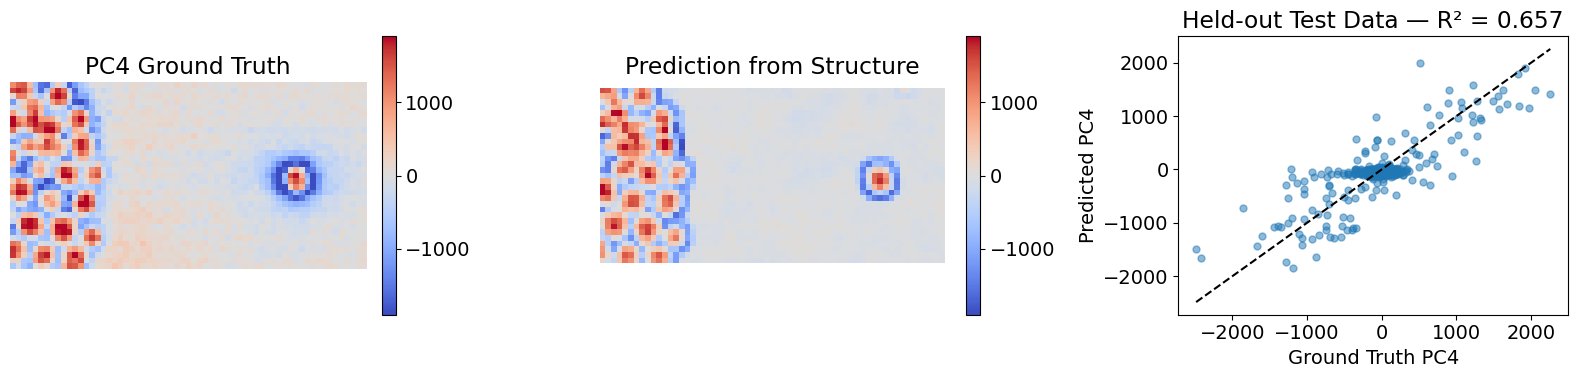

In [16]:
# Size of valid prediction region
map_shape = (
    H - 2 * half,
    W - 2 * half
)

# Predict all valid patches and reshape into their spatial region
predicted_full = model.predict(X).reshape(map_shape)

# Put predictions back into an image of the original size
prediction_map = np.full((H, W), np.nan)
prediction_map[
    half:H-half,
    half:W-half
] = predicted_full

# Use the same symmetric color scale for ground truth and prediction
combined = np.concatenate([
    scalarizer_map[np.isfinite(scalarizer_map)].ravel(),
    prediction_map[np.isfinite(prediction_map)].ravel()
])
vmax = np.nanpercentile(np.abs(combined), 99)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

im0 = ax[0].imshow(
    scalarizer_map,
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax
)
ax[0].set_title("PC4 Ground Truth")
ax[0].axis("off")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(
    prediction_map,
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax
)
ax[1].set_title("Prediction from Structure")
ax[1].axis("off")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

ax[2].scatter(y_test, predictions, alpha=0.5, s=25)
low = min(y_test.min(), predictions.min())
high = max(y_test.max(), predictions.max())
ax[2].plot([low, high], [low, high], "k--", linewidth=1.5)
ax[2].set_xlabel("Ground Truth PC4")
ax[2].set_ylabel("Predicted PC4")
ax[2].set_title(f"Held-out Test Data — R² = {r2:.3f}")

plt.tight_layout()
plt.show()


## <font color = "purple">**10.**</font> Compare Descriptor–Regressor Combinations

To make the exploration systematic, we compare descriptors of increasing structural content:

1. **Intensity only** — the simplest possible structural descriptor.
2. **Basic statistics** — mean, standard deviation, and intensity range.
3. **Edge-aware descriptor** — basic statistics plus mean gradient magnitude.
4. **Local structure descriptor** — edge-aware features plus center-to-neighborhood contrast.

We compare these with three nonlinear regressors that represent different model families:

- **MLP** — a small neural network that can learn flexible nonlinear relationships,
- **Random forest** — a tree ensemble that captures nonlinear interactions without feature scaling,
- **RBF-SVR** — a kernel method that is effective for small, low-dimensional descriptor spaces.

MLP and SVR are wrapped with standardization because they are sensitive to feature scale. All descriptor–regressor combinations use exactly the same train/test indices for a fair comparison.


Intensity only       | MLP            | R² = 0.435
Intensity only       | Random forest  | R² = 0.331
Intensity only       | RBF-SVR        | R² = 0.353
Basic statistics     | MLP            | R² = 0.516
Basic statistics     | Random forest  | R² = 0.500
Basic statistics     | RBF-SVR        | R² = 0.339
Edge-aware           | MLP            | R² = 0.507
Edge-aware           | Random forest  | R² = 0.496
Edge-aware           | RBF-SVR        | R² = 0.321
Local structure      | MLP            | R² = 0.637
Local structure      | Random forest  | R² = 0.678
Local structure      | RBF-SVR        | R² = 0.397


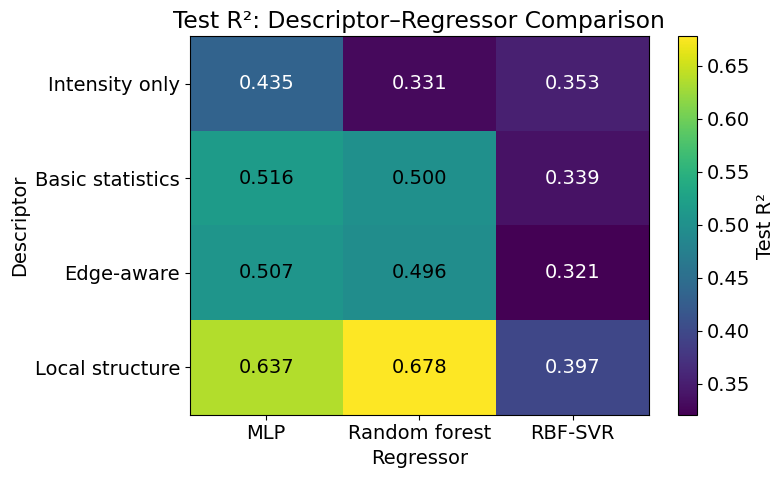


Feature counts:
  Intensity only      : 1
  Basic statistics    : 3
  Edge-aware          : 4
  Local structure     : 5


In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# ------------------------------------------------------------
# Descriptor definitions
# ------------------------------------------------------------

def descriptor_intensity(patch):
    p = patch.astype(float)
    return [p.mean()]


def descriptor_basic(patch):
    p = patch.astype(float)
    return [
        p.mean(),
        p.std(),
        p.max() - p.min(),
    ]


def descriptor_edge(patch):
    p = patch.astype(float)
    gx = sobel(p, axis=1)
    gy = sobel(p, axis=0)
    grad = np.sqrt(gx**2 + gy**2)

    return [
        p.mean(),
        p.std(),
        p.max() - p.min(),
        grad.mean(),
    ]


def descriptor_local_structure(patch):
    p = patch.astype(float)
    gx = sobel(p, axis=1)
    gy = sobel(p, axis=0)
    grad = np.sqrt(gx**2 + gy**2)

    cy = p.shape[0] // 2
    cx = p.shape[1] // 2

    return [
        p.mean(),
        p.std(),
        p.max() - p.min(),
        grad.mean(),
        p[cy, cx] - p.mean(),
    ]


descriptors = {
    "Intensity only": descriptor_intensity,
    "Basic statistics": descriptor_basic,
    "Edge-aware": descriptor_edge,
    "Local structure": descriptor_local_structure,
}

# ------------------------------------------------------------
# Regressor definitions
# ------------------------------------------------------------
# Each entry is a factory so every descriptor gets a fresh model.

regressors = {
    "MLP": lambda: make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=0,
        )
    ),

    "Random forest": lambda: RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=0,
        n_jobs=-1,
    ),

    "RBF-SVR": lambda: make_pipeline(
        StandardScaler(),
        SVR(
            kernel="rbf",
            C=10.0,
            gamma="scale",
            epsilon=0.1,
        )
    ),
}

# ------------------------------------------------------------
# Fixed train/test indices for every combination
# ------------------------------------------------------------
all_indices = np.arange(len(patches))
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.25,
    random_state=0
)

results = np.zeros((len(descriptors), len(regressors)))
feature_counts = {}
trained_models = {}
feature_matrices = {}

for i, (desc_name, desc_fn) in enumerate(descriptors.items()):

    X_desc = np.asarray([desc_fn(p) for p in patches])
    feature_matrices[desc_name] = X_desc
    feature_counts[desc_name] = X_desc.shape[1]

    for j, (reg_name, reg_fn) in enumerate(regressors.items()):

        m = reg_fn()
        m.fit(X_desc[train_idx], targets[train_idx])
        pred = m.predict(X_desc[test_idx])

        score = r2_score(targets[test_idx], pred)
        results[i, j] = score
        trained_models[(desc_name, reg_name)] = m

        print(
            f"{desc_name:20s} | "
            f"{reg_name:14s} | "
            f"R² = {score:.3f}"
        )

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(results, cmap="viridis", aspect="auto")

ax.set_xticks(np.arange(len(regressors)))
ax.set_xticklabels(list(regressors.keys()))
ax.set_yticks(np.arange(len(descriptors)))
ax.set_yticklabels(list(descriptors.keys()))

ax.set_xlabel("Regressor")
ax.set_ylabel("Descriptor")
ax.set_title("Test R²: Descriptor–Regressor Comparison")

for i in range(results.shape[0]):
    for j in range(results.shape[1]):
        ax.text(
            j, i,
            f"{results[i, j]:.3f}",
            ha="center",
            va="center",
            color="white" if results[i, j] < np.nanmax(results)*0.65 else "black"
        )

plt.colorbar(im, ax=ax, label="Test R²")
plt.tight_layout()
plt.show()

print("\nFeature counts:")
for name, count in feature_counts.items():
    print(f"  {name:20s}: {count}")


## <font color = "purple">**11.**</font> Best Model and Explainability

We now identify the highest-scoring descriptor–regressor pair automatically. Because the candidate regressors are nonlinear and use different model families, we use **permutation importance** for a common model-agnostic interpretation.

Permutation importance asks: *how much does the held-out test R² decrease when one structural feature is randomly shuffled?* A larger decrease means that feature carries more predictive information for the PC4 EELS response.

This lets us report not only the best predictive combination, but also which simple structural quantities are most useful for learning the structure → property relationship.


BEST RESULT
--------------------------------------------------
Descriptor : Local structure
Regressor  : Random forest
Features   : 5
Test R²    : 0.678

Permutation feature importance:
  Mean intensity       +1.3655 ± 0.1063
  Center contrast      +0.4778 ± 0.0438
  Intensity range      +0.1203 ± 0.0162
  Std intensity        +0.0903 ± 0.0114
  Mean gradient        +0.0316 ± 0.0100


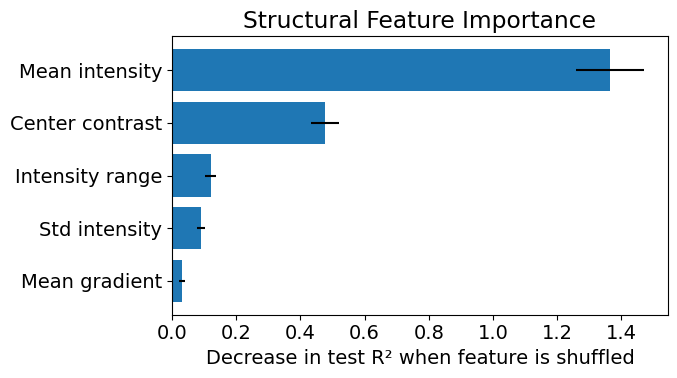

In [18]:
from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# Identify best combination
# ------------------------------------------------------------
best_flat = np.nanargmax(results)
best_i, best_j = np.unravel_index(best_flat, results.shape)

best_descriptor_name = list(descriptors.keys())[best_i]
best_regressor_name = list(regressors.keys())[best_j]
best_r2 = results[best_i, best_j]

best_X = feature_matrices[best_descriptor_name]
best_model = trained_models[(best_descriptor_name, best_regressor_name)]

print("BEST RESULT")
print("-" * 50)
print("Descriptor :", best_descriptor_name)
print("Regressor  :", best_regressor_name)
print("Features   :", best_X.shape[1])
print(f"Test R²    : {best_r2:.3f}")

# ------------------------------------------------------------
# Feature names for explainability
# ------------------------------------------------------------
feature_name_map = {
    "Intensity only": [
        "Mean intensity"
    ],
    "Basic statistics": [
        "Mean intensity",
        "Std intensity",
        "Intensity range",
    ],
    "Edge-aware": [
        "Mean intensity",
        "Std intensity",
        "Intensity range",
        "Mean gradient",
    ],
    "Local structure": [
        "Mean intensity",
        "Std intensity",
        "Intensity range",
        "Mean gradient",
        "Center contrast",
    ],
}

best_feature_names = feature_name_map[best_descriptor_name]

# ------------------------------------------------------------
# Model-agnostic permutation importance on held-out test data
# ------------------------------------------------------------
perm = permutation_importance(
    best_model,
    best_X[test_idx],
    targets[test_idx],
    scoring="r2",
    n_repeats=20,
    random_state=0
)

order = np.argsort(perm.importances_mean)[::-1]

print("\nPermutation feature importance:")
for idx in order:
    print(
        f"  {best_feature_names[idx]:20s} "
        f"{perm.importances_mean[idx]:+.4f} "
        f"± {perm.importances_std[idx]:.4f}"
    )

# ------------------------------------------------------------
# Importance plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.barh(
    np.array(best_feature_names)[order][::-1],
    perm.importances_mean[order][::-1],
    xerr=perm.importances_std[order][::-1]
)
plt.xlabel("Decrease in test R² when feature is shuffled")
plt.title("Structural Feature Importance")
plt.tight_layout()
plt.show()


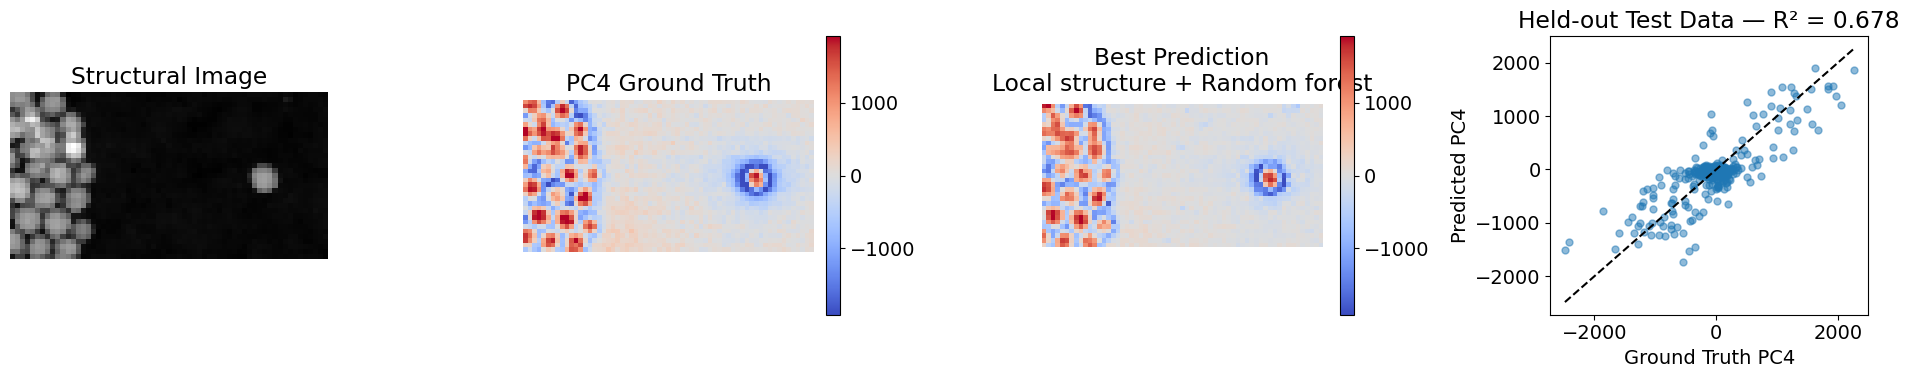

In [19]:
# ------------------------------------------------------------
# Final spatial result for the best combination
# ------------------------------------------------------------
best_pred_test = best_model.predict(best_X[test_idx])
best_pred_all = best_model.predict(best_X)

best_prediction_map = np.full((H, W), np.nan)
for (y_pos, x_pos), pred in zip(coords, best_pred_all):
    best_prediction_map[y_pos, x_pos] = pred

combined = np.concatenate([
    scalarizer_map[np.isfinite(scalarizer_map)].ravel(),
    best_prediction_map[np.isfinite(best_prediction_map)].ravel()
])
vmax = np.nanpercentile(np.abs(combined), 99)

fig, ax = plt.subplots(1, 4, figsize=(19, 4))

ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")
ax[0].axis("off")

im1 = ax[1].imshow(
    scalarizer_map,
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax
)
ax[1].set_title("PC4 Ground Truth")
ax[1].axis("off")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(
    best_prediction_map,
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax
)
ax[2].set_title(
    f"Best Prediction\n{best_descriptor_name} + {best_regressor_name}"
)
ax[2].axis("off")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

ax[3].scatter(
    targets[test_idx],
    best_pred_test,
    alpha=0.5,
    s=25
)
lo = min(targets[test_idx].min(), best_pred_test.min())
hi = max(targets[test_idx].max(), best_pred_test.max())
ax[3].plot([lo, hi], [lo, hi], "k--", linewidth=1.5)
ax[3].set_xlabel("Ground Truth PC4")
ax[3].set_ylabel("Predicted PC4")
ax[3].set_title(f"Held-out Test Data — R² = {best_r2:.3f}")

plt.tight_layout()
plt.show()


### How to interpret the final result

- **PC4 is the property scalarizer:** it represents a particle-localized EELS spectral variation that visibly distinguishes bulk/interior and edge-associated response.
- **The descriptor represents structure:** the candidate features describe local intensity, heterogeneity, contrast, and boundary information in the structural image.
- **The regressor creates the structure → property mapping:** it tests whether those local structural quantities predict the PC4 score.
- **The heatmap answers the performance/complexity trade-off:** it shows whether extra descriptor complexity or nonlinear regression produces a meaningful gain.
- **Permutation importance answers explainability:** it identifies which local structural quantities contribute most to predicting the PC4 response.

The final choice should therefore not be based only on the highest R². If a simpler descriptor/regressor combination performs nearly as well as the absolute best model, the simpler combination better satisfies the challenge goal of **predictive power + low complexity + explainability**.


### Final question

> Which descriptor–regressor combination gives the best predictive performance while remaining simple and explainable?

Use the Section 10 heatmap together with the automatically reported result and feature importance in Section 11. If the nonlinear model improves R² only marginally over a linear model, prefer the simpler linear solution; if the improvement is substantial, report the nonlinear benchmark but keep the descriptor interpretation explicit.
